# Import essential libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

In [ ]:
pd.set_option('display.max_columns', None)

Insight:
We import standard libraries for data analysis (pandas, numpy), visualization (matplotlib, seaborn), ML (scikit-learn), and XAI (shap).

# Load the UCI Cleveland Heart Disease dataset

In [ ]:
# Dataset URL
UCI_CLEVELAND_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

In [ ]:
# Column names (as per UCI documentation)
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

About This Data :

1.   age: age in years
2.   sex: sex (1 = male; 0 = female)
3.   cp: chest pain type

*   -- Value 0: typical angina
*   -- Value 1: atypical angina
*   -- Value 2: non-anginal pain
*   -- Value 3: asymptomatic

4.  trestbps: resting blood pressure (in mm Hg on admission to the hospital)
5.  chol: serum cholestoral in mg/dl
6.  fbs: (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
7.  restecg: resting electrocardiographic results
*   -- Value 0: normal
*   -- Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
*   -- Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
8.  thalach: maximum heart rate achieved
9.  exang: exercise induced angina (1 = yes; 0 = no)
10. oldpeak = ST depression induced by exercise relative to rest
11. slope: the slope of the peak exercise ST segment
*   -- Value 1: upsloping
*   -- Value 2: flat
*   -- Value 3: downsloping
12. ca: number of major vessels (0-3) colored by flourosopy
13. thal: 3 = normal, 6 = fixed defect (i.e., defect that does not change with stress), 7 = reversible defect (i.e., shows up during stress but resolves at rest)
14. condition:
* 0 = no heart disease (i.e., < 50% diameter narrowing)
* 1, 2, 3, 4 = presence of heart disease (i.e., > 50% diameter narrowing in any major vessel)

In [ ]:
# Load dataset
data = pd.read_csv(UCI_CLEVELAND_URL, names=columns)

In [ ]:
# Display top 5 rows
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [ ]:
data.shape

(303, 14)

Insight:
This dataset contains 303 rows and 14 columns — features include age, sex, cholesterol, etc. The target column indicates the presence of heart disease (values 0–4).

# Data Cleaning & Preprocessing

In [ ]:
data.duplicated().sum() #Checks the duplicates

np.int64(0)

In [ ]:
# Replace missing values marked as '?'
data = data.replace('?', np.nan)

In [ ]:
# Convert columns to numeric
data = data.apply(pd.to_numeric)

In [ ]:
# Display missing values
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [ ]:
# Drop rows with missing values
data = data.dropna()

In [ ]:
# Verify shape after cleaning
print("\nData shape after cleaning:", data.shape)


Data shape after cleaning: (297, 14)


Insight:
UCI dataset uses '?' for missing data. We replace them with NaN and drop incomplete rows.
Final dataset typically has ~297 samples.

# Target Encoding (Binary classification)

In [ ]:
# Convert target (0 = no disease, 1–4 = disease)
data['target'] = data['target'].apply(lambda x: 1 if x > 0 else 0)

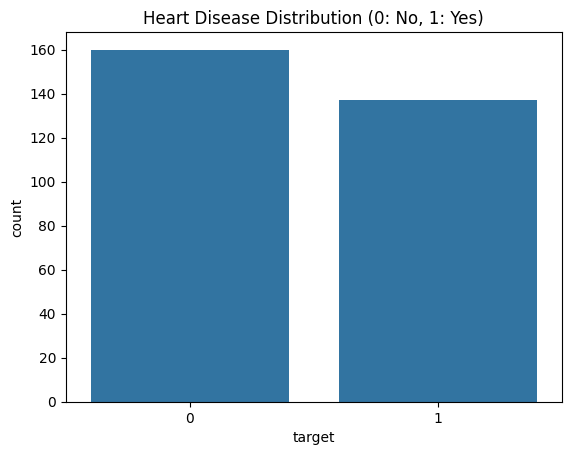

In [ ]:
# Check target distribution
sns.countplot(x='target', data=data)
plt.title("Heart Disease Distribution (0: No, 1: Yes)")
plt.show()


In [ ]:
data['target'].value_counts()

,count
target,
0,160
1,137


Insight:
We transform the multi-class target (0–4) into binary classification:
0 → No Disease, 1 → Disease.
This makes it clinically relevant (predict risk presence).

# Feature-target split

In [ ]:
X = data.drop('target', axis=1)
y = data['target']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (297, 13)
Target shape: (297,)


# Data scaling & train-test split

In [ ]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Train samples: 237
Test samples: 60


Insight:
We scale features for better model stability, especially for models sensitive to feature magnitude.

# Train the Random Forest Model

In [ ]:
# Initialize and train model
rf_model = RandomForestClassifier(n_estimators=200,max_depth=5,random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict
y_pred = rf_model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8333333333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.85        32
           1       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



# Confusion Matrix & ROC Curve

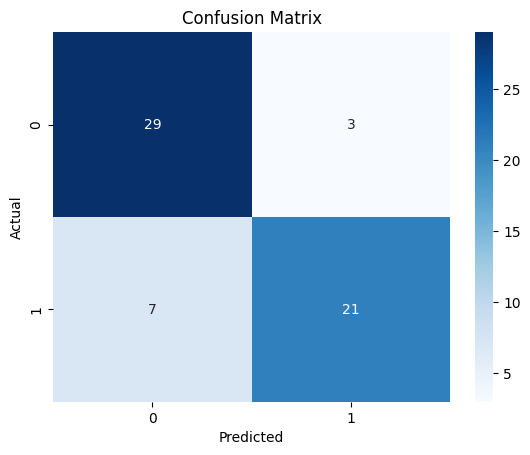

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

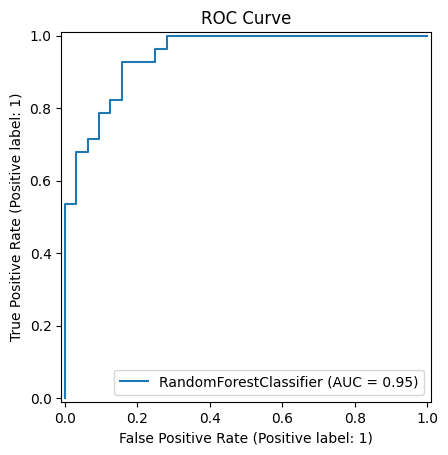

ROC AUC Score: 0.9464285714285714


In [ ]:
# ROC Curve
RocCurveDisplay.from_estimator(rf_model, X_test_scaled, y_test)
plt.title("ROC Curve")
plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:,1]))


In [ ]:
from sklearn.metrics import roc_curve

# Get probabilities for positive class
y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Find best threshold where recall is high but FPR reasonable
import numpy as np
best_thresh = thresholds[np.argmax(tpr - fpr)]
print("Best threshold:", best_thresh)


Best threshold: 0.3900717580361332


In [ ]:
y_pred_opt = (y_proba >= best_thresh).astype(int)

In [ ]:
y_pred_opt

array([0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1])

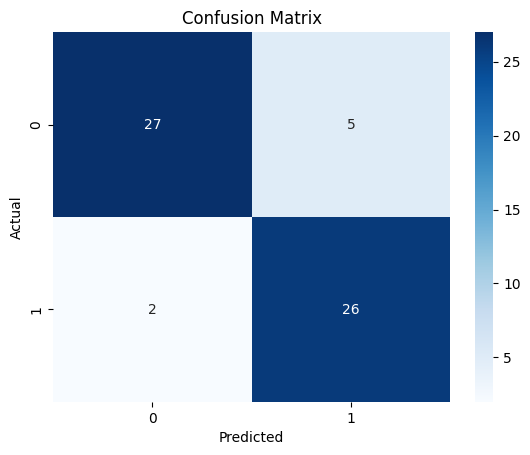

In [ ]:
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Insights

Confusion matrix shows few misclassifications → strong accuracy.

Low false negatives → good recall.

ROC curve shows excellent class separation.

AUC = 0.95 → high model performance overall.

# Global Feature Importance

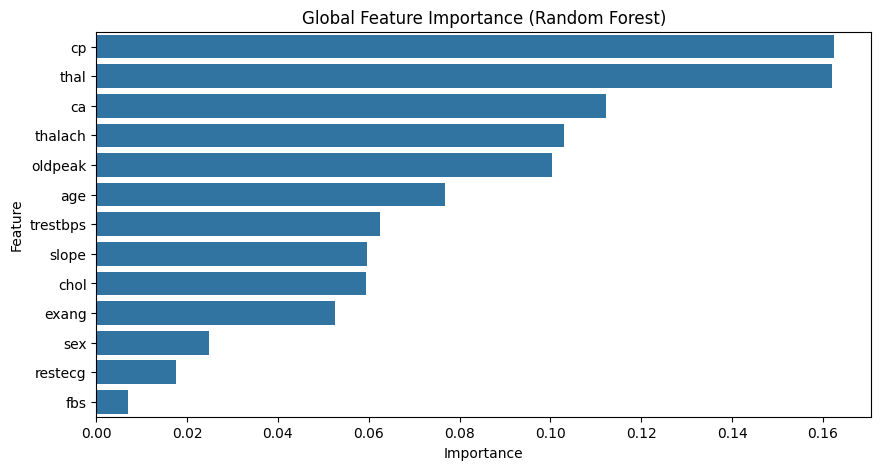

In [ ]:
# Plot feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title("Global Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


Insight:
Shows which features globally contribute most to predictions (e.g., oldpeak, cp, thalach, ca, etc.).

In [ ]:
# --- Use top 5 features from Random Forest importance ---
top_features = [X.columns[i] for i in indices[:5]]

print("Top 5 important features (by Random Forest):")
for i, f in enumerate(top_features, 1):
    print(f"{i}. {f}")


Top 5 important features (by Random Forest):
1. cp
2. thal
3. ca
4. thalach
5. oldpeak


# Explainable AI (SHAP) – Initialization

In [ ]:
import shap

# Convert scaled data back to a DataFrame for readability
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Initialize the explainer
explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values on scaled test data
shap_values = explainer.shap_values(X_test_scaled)


Using SHAP shape: (60, 13)


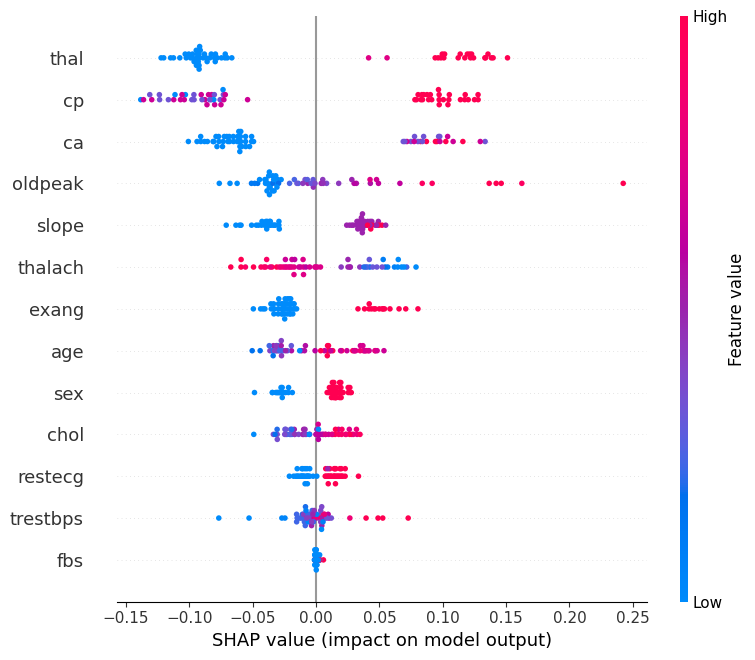

In [ ]:
# Handle both possible SHAP return formats (list vs. array)
if isinstance(shap_values, list):
    shap_values_used = shap_values[1]   # positive class (1 = heart disease)
else:
  # shap_values shape might be (n_samples, n_features, n_classes)
  if shap_values.ndim == 3:
    shap_values_used = shap_values[:, :, 1]
  else:
    shap_values_used = shap_values # fallback for single-output models

print('Using SHAP shape:', shap_values_used.shape)

# Global summary
shap.summary_plot(shap_values_used, X_test_scaled_df, feature_names=X.columns)


Insight:
SHAP summary plot shows global impact of each feature on model output.
Features at the top are the most influential across all samples.

# SHAP Dependence Plot

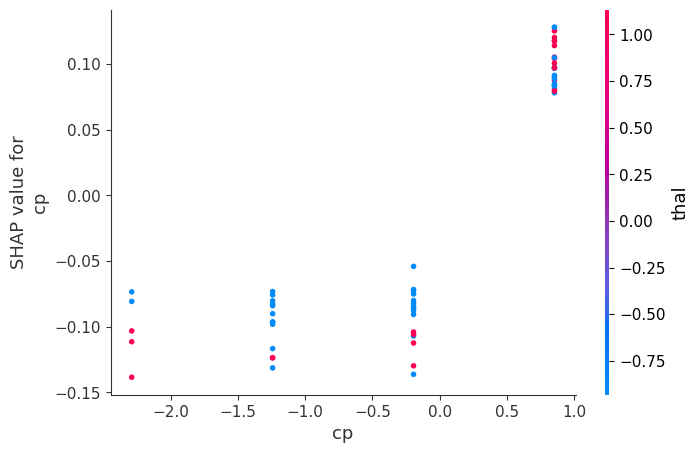

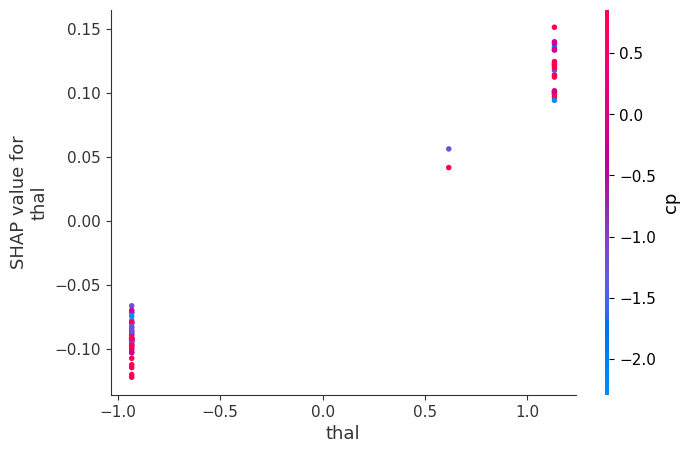

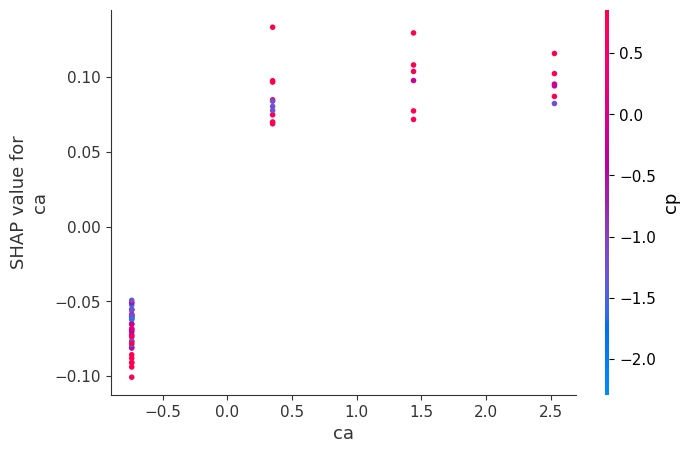

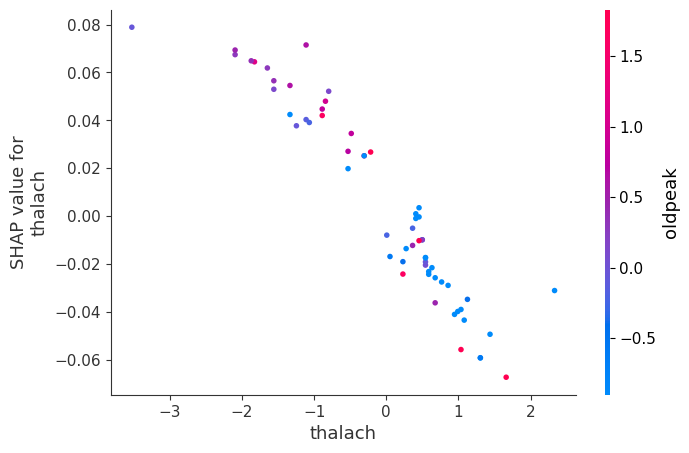

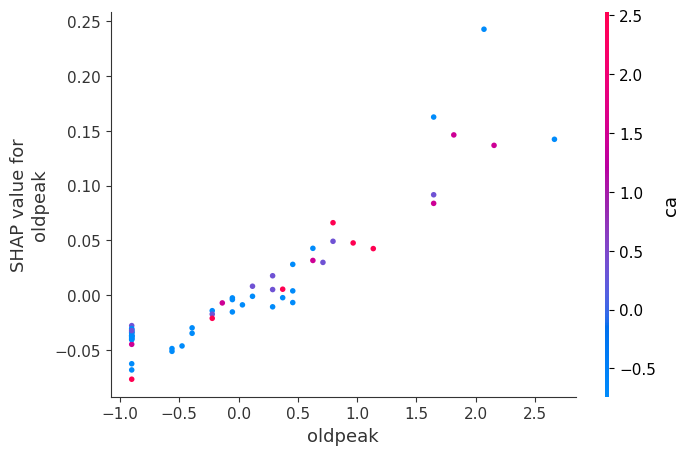

In [ ]:
for feature in top_features:
    shap.dependence_plot(feature, shap_values_used, X_test_scaled_df, feature_names=X.columns)

Points farther to the right (higher oldpeak) usually have higher SHAP values,
meaning they increase cardiovascular risk.

The color gradient represents another correlated feature (SHAP automatically picks the most interacting one, e.g. slope).

# SHAP Local Explanation (Single Patient)

Base value (expected): 0.46563291139240515
Sum of SHAP values: -0.40736637834467126
Raw model output (logit): 0.05826653304773388
Predicted probability: 0.5145625135307514


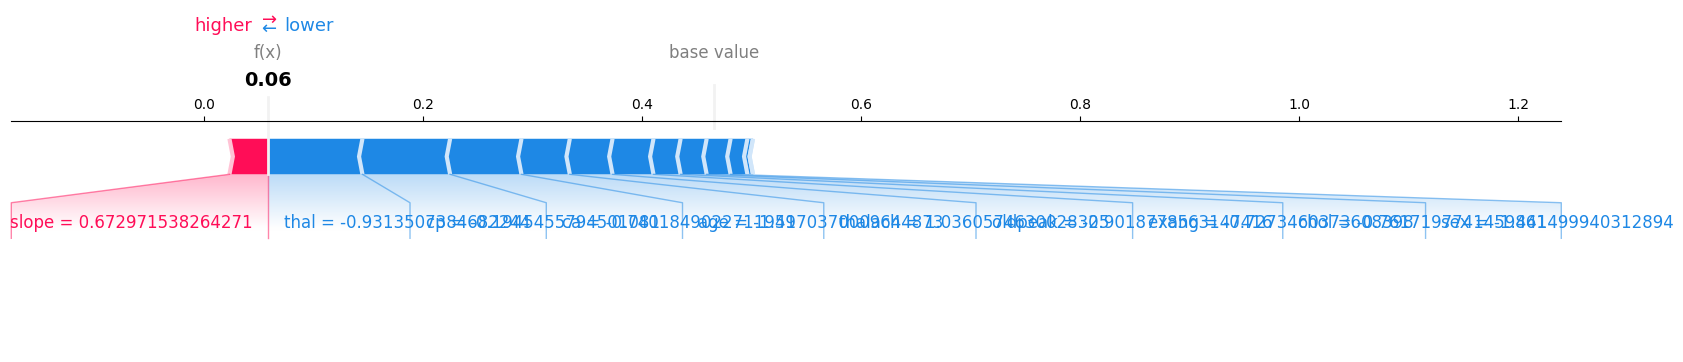

In [ ]:
# Choose one patient sample
sample_idx = 5

# Extract the sample (scaled data for consistency)
sample = X_test_scaled_df.iloc[sample_idx:sample_idx+1]

# Extract SHAP values for the positive class (1)
shap_values_used = shap_values[:, :, 1]   # shape: (n_samples, n_features)
sample_shap_values = shap_values_used[sample_idx]

# Calculate base value and SHAP contribution
base_value = explainer.expected_value[1]  # expected value for class 1
shap_sum = sample_shap_values.sum()
actual_prediction_logit = base_value + shap_sum  # model output before sigmoid
actual_prediction_prob = 1 / (1 + np.exp(-actual_prediction_logit))  # convert logit to probability

# Print the results
print("Base value (expected):", base_value)
print("Sum of SHAP values:", shap_sum)
print("Raw model output (logit):", actual_prediction_logit)
print("Predicted probability:", actual_prediction_prob)

# --- SHAP Force Plot ---
shap.initjs()
shap.force_plot(
    base_value,
    sample_shap_values,
    sample,
    matplotlib=True
)


Base value (expected value): the model’s average output for class 1 across all samples.

Red bars: features that increase heart-disease risk for this patient.

Blue bars: features that decrease risk.

The final value on the right is the model’s predicted probability for heart disease.

Insight:

The model predicts low heart disease risk (0.06).
Most features (blue) lowered risk, especially thal and cp.
Only slope slightly increased risk, but not enough to change the final outcome.

# Save Model for Deployment

In [ ]:
import joblib

# Save trained model and scaler
joblib.dump(rf_model, "rf_heart_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print(" Model and scaler saved for deployment.")


 Model and scaler saved for deployment.


Insight:
You can later load these files in your FastAPI backend to serve predictions on web.

# Compare with Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
print("Accuracy (Logistic Regression):", accuracy_score(y_test, y_pred_lr))
print("ROC AUC (LR):", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]))


Accuracy (Logistic Regression): 0.8333333333333334
ROC AUC (LR): 0.9497767857142857


Insights:

Both models perform well (AUC ≈ 0.95).

Random Forest slightly higher accuracy → better overall prediction.

Logistic Regression nearly equal AUC → simpler and easier to interpret.

So i choose Random Forest for best performance

In [ ]:
import numpy as np
import pandas as pd

# Function to take user input with normal reference ranges
def get_user_input():
    print("Enter patient details (normal ranges shown for reference):\n")

    age = float(input("Age (years) [Normal: 20–80]: "))
    sex = int(input("Sex (1 = male, 0 = female): "))
    cp = int(input("Chest pain type (0–3) [0=typical, 1=atypical, 2=non-anginal, 3=asymptomatic]: "))
    trestbps = float(input("Resting blood pressure (mm Hg) [Normal: 90–140]: "))
    chol = float(input("Serum cholesterol (mg/dl) [Normal: <200]: "))
    fbs = int(input("Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) [Normal: 0]: "))
    restecg = int(input("Resting ECG results (0–2) [0=normal, 1=ST-T abnormality, 2=LV hypertrophy]: "))
    thalach = float(input("Max heart rate achieved [Normal: 60–200]: "))
    exang = int(input("Exercise induced angina (1 = yes, 0 = no) [Normal: 0]: "))
    oldpeak = float(input("ST depression induced by exercise [Normal: 0–2]: "))
    slope = int(input("Slope of peak exercise ST segment (0–2) [0=upsloping, 1=flat, 2=downsloping]: "))
    ca = int(input("Number of major vessels (0–3) [Normal: 0]: "))
    thal = int(input("Thal (0 = normal; 1 = fixed defect; 2 = reversible defect) [Normal: 0]: "))

    # Combine inputs into DataFrame
    data = pd.DataFrame({
        'age': [age], 'sex': [sex], 'cp': [cp], 'trestbps': [trestbps],
        'chol': [chol], 'fbs': [fbs], 'restecg': [restecg], 'thalach': [thalach],
        'exang': [exang], 'oldpeak': [oldpeak], 'slope': [slope],
        'ca': [ca], 'thal': [thal]
    })
    return data


In [ ]:
# Get input from user
user_data = get_user_input()

# Scale it using the same scaler used for training
user_data_scaled = scaler.transform(user_data)

# Predict the probability and class
prediction = rf_model.predict(user_data_scaled)
probability = rf_model.predict_proba(user_data_scaled)[0][1]

# Display result
print("\n🩺 Cardiovascular Risk Assessment Result:")
print(f"Predicted Class: {'Heart Disease Detected' if prediction[0] == 1 else 'No Heart Disease'}")
print(f"Prediction Probability (risk score): {probability:.2f}")



Enter patient details (normal ranges shown for reference):



In [ ]:
# Get SHAP values for the user input
shap_value_user = explainer.shap_values(user_data_scaled)

# Show SHAP force plot for that prediction
shap.initjs()
if isinstance(shap_value_user, list):
    shap.force_plot(explainer.expected_value[1], shap_value_user[1][0], user_data)
else:
    shap.force_plot(explainer.expected_value[1], shap_value_user[0, :, 1], user_data)


In [ ]:
# For Jupyter interactive visualization
shap.force_plot(
    explainer.expected_value[1],
    shap_value_user[:, :, 1][0],
    user_data,
    matplotlib=True
)


In [ ]:
!pip install streamlit shap scikit-learn matplotlib numpy pandas joblib


In [ ]:
from google.colab import files
files.download("rf_heart_model.pkl")
files.download("scaler.pkl")

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

# Load model and scaler
model = joblib.load("rf_heart_model.pkl")
scaler = joblib.load("scaler.pkl")

# Define features
features = ["age", "sex", "cp", "trestbps", "chol", "fbs",
            "restecg", "thalach", "exang", "oldpeak", "slope",
            "ca", "thal"]

st.set_page_config(page_title="💓 Explainable AI: Heart Risk Assessment", layout="centered")

st.title("💓 Explainable AI for Cardiovascular Risk Assessment")
st.markdown("This AI model predicts heart disease risk and explains it using **SHAP** (Explainable AI).")

# Input fields for user data
st.sidebar.header("Enter your health data:")
user_data = {}
for feature in features:
    user_data[feature] = st.sidebar.number_input(f"{feature}", min_value=0.0, step=0.1)

user_df = pd.DataFrame([user_data])

# Scale input
user_scaled = scaler.transform(user_df)

# Predict
pred = model.predict(user_scaled)[0]
proba = model.predict_proba(user_scaled)[0][1]

st.subheader("🩺 Prediction Result")
if pred == 1:
    st.error(f"⚠️ High risk of heart disease (Confidence: {proba:.2f})")
else:
    st.success(f"✅ Low risk of heart disease (Confidence: {1 - proba:.2f})")

# Explainable AI (SHAP)
st.subheader("🔍 Model Explanation (SHAP)")

explainer = shap.Explainer(model, user_scaled)
shap_values = explainer(user_scaled)

# SHAP force plot
st.markdown("### Feature Contribution Visualization:")
fig, ax = plt.subplots()
shap.waterfall_plot(shap.Explanation(values=shap_values.values[0, :, 1], # Select SHAP values for positive class and first sample
                                     base_values=shap_values.base_values[0, 1], # Select base value for positive class and first sample
                                     feature_names=features,
                                     data=user_df.iloc[0].values))
st.pyplot(fig)

st.markdown("---")
st.markdown("👩‍⚕️ *Powered by Explainable AI – providing transparency in healthcare decisions.*")

In [ ]:
import sys
import os
# Add the directory containing installed packages to the PATH
sys.path.append(os.path.abspath(os.path.join(sys.executable, '../lib/python*/site-packages')))

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

# Load model and scaler
model = joblib.load("rf_heart_model.pkl")
scaler = joblib.load("scaler.pkl")

# Define features
features = ["age", "sex", "cp", "trestbps", "chol", "fbs",
            "restecg", "thalach", "exang", "oldpeak", "slope",
            "ca", "thal"]

st.set_page_config(page_title="💓 Explainable AI: Heart Risk Assessment", layout="centered")

st.title("💓 Explainable AI for Cardiovascular Risk Assessment")
st.markdown("This AI model predicts heart disease risk and explains it using **SHAP** (Explainable AI).")

# Input fields for user data
st.sidebar.header("Enter your health data:")
user_data = {}
for feature in features:
    user_data[feature] = st.sidebar.number_input(f"{feature}", min_value=0.0, step=0.1)

user_df = pd.DataFrame([user_data])

# Scale input
user_scaled = scaler.transform(user_df)

# Predict
pred = model.predict(user_scaled)[0]
proba = model.predict_proba(user_scaled)[0][1]

st.subheader("🩺 Prediction Result")
if pred == 1:
    st.error(f"⚠️ High risk of heart disease (Confidence: {proba:.2f})")
else:
    st.success(f"✅ Low risk of heart disease (Confidence: {1 - proba:.2f})")

# Explainable AI (SHAP)
st.subheader("🔍 Model Explanation (SHAP)")

explainer = shap.Explainer(model, user_scaled)
shap_values = explainer(user_scaled)

# SHAP force plot
st.markdown("### Feature Contribution Visualization:")
fig, ax = plt.subplots()
shap.waterfall_plot(shap.Explanation(values=shap_values.values[0, :, 1], # Select SHAP values for positive class and first sample
                                     base_values=shap_values.base_values[0, 1], # Select base value for positive class and first sample
                                     feature_names=features,
                                     data=user_df.iloc[0].values))
st.pyplot(fig)

st.markdown("---")
st.markdown("👩‍⚕️ *Powered by Explainable AI – providing transparency in healthcare decisions.*")

In [ ]:
!pip install pyngrok

In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("32YuyrAW3D1qJfvmqlSHzqjsWSd_BD96JnyTZMuhynBTTyvY")

public_url = ngrok.connect(8501)
print(f"🌐 Your Streamlit app is live here: {public_url}")



In [ ]:
!streamlit run app.py